In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/btc-data/BTC.csv


In [4]:
#Import required libraries
import math
import time
import datetime
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import optuna
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from keras.models import save_model
from keras.layers import SimpleRNN, LSTM, GRU, Bidirectional, Dense, Dropout
from keras.layers import MultiHeadAttention, LayerNormalization, Input, GlobalAveragePooling1D, Embedding, Add
from tensorflow.keras.callbacks import EarlyStopping
from statsmodels.tsa.holtwinters import ExponentialSmoothing
from keras.optimizers import Adam
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score, explained_variance_score
from keras.models import Sequential, Model
from hyperopt import fmin, tpe, hp, Trials, STATUS_OK, STATUS_FAIL, space_eval
import tensorflow as tf
from keras.models import load_model
import os
from tensorflow.keras import backend as K
from optuna.integration import TFKerasPruningCallback


# Importing the CSV file
df = pd.read_csv("/Applications/forvscode/BachelorFinal/Hybrid-models-for-TS-processing/docs/BTC.csv")

# Sorting the DataFrame by the date column
df = df.sort_values(by='Date')

df.isnull().sum()

# Convert the 'Date' column to datetime format
df['Date'] = pd.to_datetime(df['Date'])

# Set the 'Date' column as the index
df.set_index('Date', inplace=True)


# Prepare the data
close_prices = df['Close'].astype(float)

# Length of training data
training_data_len = math.ceil(len(close_prices) * 0.80)

time_step = 30

# Split close into train/test (ONLY close, no HW yet)
train_close = close_prices.iloc[:training_data_len]
test_close  = close_prices.iloc[training_data_len:]

# Fit Holt-Winters ONLY on train
hw_model = ExponentialSmoothing(train_close, trend='mul', seasonal='mul', seasonal_periods=365)
hw_fit = hw_model.fit()

# Base line for train (in-sample) and test (forecast)
base_train = hw_fit.fittedvalues.reindex(train_close.index)
base_train = base_train.fillna(train_close)  # safety: avoid NaNs -> ratio=1 for those points

base_test = hw_fit.forecast(len(test_close))

# Ratio (residual) series: this is what NN will model
ratio_train = (train_close / base_train).to_numpy()
ratio_test  = (test_close  / base_test).to_numpy()

# Build test_values with overlap of last time_step from train (needed for windowing)
train_values = ratio_train
test_values  = np.concatenate([ratio_train[-time_step:], ratio_test])

# Normalize using only training data
scaler = MinMaxScaler(feature_range=(0, 1))
scaled_train = scaler.fit_transform(train_values.reshape(-1, 1))
scaled_test = scaler.transform(test_values.reshape(-1, 1))

# Build training sequences
x_train, y_train = [], []
for i in range(time_step, len(scaled_train)):
    x_train.append(scaled_train[i - time_step:i, 0])
    y_train.append(scaled_train[i, 0])

x_train = np.array(x_train)
y_train = np.array(y_train)
x_train = np.reshape(x_train, (x_train.shape[0], x_train.shape[1], 1))

# Build test sequences
x_test = []
for i in range(time_step, len(scaled_test)):
    x_test.append(scaled_test[i - time_step:i, 0])

x_test = np.array(x_test)
x_test = np.reshape(x_test, (x_test.shape[0], x_test.shape[1], 1))

# True y_test is the REAL close on test (as before)
y_test = test_close.to_numpy()


# Define the Mish activation function
def mish(x):
    return x * K.tanh(K.softplus(x))

# Define the objective function for Optuna
def objective(trial):
    # Hyperparameters to tune
    learning_rate = trial.suggest_float('learning_rate', 0.0001, 0.01, log=True)
    units = trial.suggest_int('units', 20, 50, step=5)
    dropout_rate = trial.suggest_float('dropout_rate', 0, 0.3)
    batch_size = trial.suggest_categorical('batch_size', [16, 32, 64, 128])
    epochs = trial.suggest_int('epochs', 50, 150, step=10)
    num_blocks = trial.suggest_int('num_blocks', 1, 4)
    num_heads = trial.suggest_int('num_heads', 2, 10, step=2)
    head_size = trial.suggest_int('head_size', 8, 64, step=8)

    # Define the model architecture
    def create_helformer_model(input_shape):
        inputs = Input(shape=input_shape)
        x = inputs

        for _ in range(num_blocks):
            x_norm1 = LayerNormalization(epsilon=1e-6)(x)
            attention_output = MultiHeadAttention(num_heads=num_heads, key_dim=head_size, dropout=dropout_rate)(x_norm1, x_norm1)
            x = x + attention_output

            x_norm2 = LayerNormalization(epsilon=1e-6)(x)
            x = x + x_norm2

        # LSTM layer
        x = LSTM(units, activation=mish, return_sequences=False)(x)

        # Output layer
        outputs = Dense(1)(x)

        model = Model(inputs=inputs, outputs=outputs)
        return model

    # Create and compile the model
    input_shape = (x_train.shape[1], x_train.shape[2])
    model = create_helformer_model(input_shape)
    model.compile(optimizer=Adam(learning_rate=learning_rate), loss='mean_squared_error')

    # Train the model
    history = model.fit(
        x_train, y_train,
        batch_size=batch_size,
        epochs=epochs,
        validation_split=0.2,
        verbose=0,
        callbacks=[TFKerasPruningCallback(trial, 'val_loss')]
    )

    # Predictions on validation data
    val_loss = min(history.history['val_loss'])
    return val_loss

# Run the Optuna optimization
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=50)

# Print the best hyperparameters
best_params = study.best_params
print("Best hyperparameters:", best_params)

/Applications/forvscode/BachelorFinal/Hybrid-models-for-TS-processing/.venv/lib/python3.11/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
/Applications/forvscode/BachelorFinal/Hybrid-models-for-TS-processing/.venv/lib/python3.11/site-packages/statsmodels/tsa/holtwinters/model.py:903: ConvergenceWarning: Optimization failed to converge. Check mle_retvals.
  warnings.warn(
[I 2025-12-20 22:12:33,835] A new study created in memory with name: no-name-db7be575-8311-4bf8-b883-9fcc68b09cfd
[I 2025-12-20 22:15:19,452] Trial 0 finished with value: 0.000569415686186403 and parameters: {'learning_rate': 0.0004939476455614464, 'units': 20, 'dropout_rate': 0.11682173678702391, 'batch_size': 32, 'epochs': 140, 'num_blocks': 4, 'num_heads': 6, 'head_size': 32}. Best is trial 0 with value: 0.000569415686186403.
[I 2025-12-20 22:16:52,708] Trial 1 finished with value: 0.00056

KeyboardInterrupt: 

In [3]:
best_params = {'learning_rate': 0.008155950097119445,
 'units': 40,
 'dropout_rate': 0.1669279324208346,
 'batch_size': 16,
 'epochs': 100,
 'num_blocks': 1,
 'num_heads': 6,
 'head_size': 64}

In [18]:
# Retrain the model using the best hyperparameters
def create_best_helformer_model(input_shape):
    inputs = Input(shape=input_shape)
    x = inputs

    for _ in range(best_params['num_blocks']):
        x_norm1 = LayerNormalization(epsilon=1e-6)(x)
        attention_output = MultiHeadAttention(num_heads=best_params['num_heads'], key_dim=best_params['head_size'], dropout=best_params['dropout_rate'])(x_norm1, x_norm1)
        x = x + attention_output

        x_norm2 = LayerNormalization(epsilon=1e-6)(x)
        x = x + x_norm2

    # LSTM layer
    x = LSTM(best_params['units'], activation=mish, return_sequences=False)(x)

    # Output layer
    outputs = Dense(1)(x)

    model = Model(inputs=inputs, outputs=outputs)
    return model

# Create and compile the model with the best parameters
final_model_Helformer = create_best_helformer_model((x_train.shape[1], x_train.shape[2]))
final_model_Helformer.compile(optimizer=Adam(learning_rate=best_params['learning_rate']), loss='mean_squared_error')

# Train the model
print("Training final Helformer model")
final_history_Helformer = final_model_Helformer.fit(x_train, y_train, batch_size=best_params['batch_size'], epochs=best_params['epochs'], verbose=1)# Verbose set to 1 for detailed output during training

final_model_Helformer.save('Main_Helformer.h5')

Training final Helformer model
Epoch 1/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 23s 45ms/step - loss: 0.0908
Epoch 2/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.5259e-04
Epoch 3/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.2732e-04
Epoch 4/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 8.9473e-04
Epoch 5/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.6171e-04
Epoch 6/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.8506e-04
Epoch 7/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.3694e-04
Epoch 8/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.7129e-04
Epoch 9/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.3959e-04
Epoch 10/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.3617e-04
Epoch 11/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010
Epoch 12/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 9.4491e-04
Epoch 13/100
136/136 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0010
Epoch 14/100
136/136 ━━━━━━━━━━━━━━━━━━

In [19]:
RESULTS_DIR = "/kaggle/working/results"
os.makedirs(RESULTS_DIR, exist_ok=True)

68/68 ━━━━━━━━━━━━━━━━━━━━ 3s 21ms/step
Predicting test data
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 51ms/step
Metrics saved to: Performance_metrics_2025-12-20_17-32-31.txt
Trading metrics saved to: Trading_metrics.txt


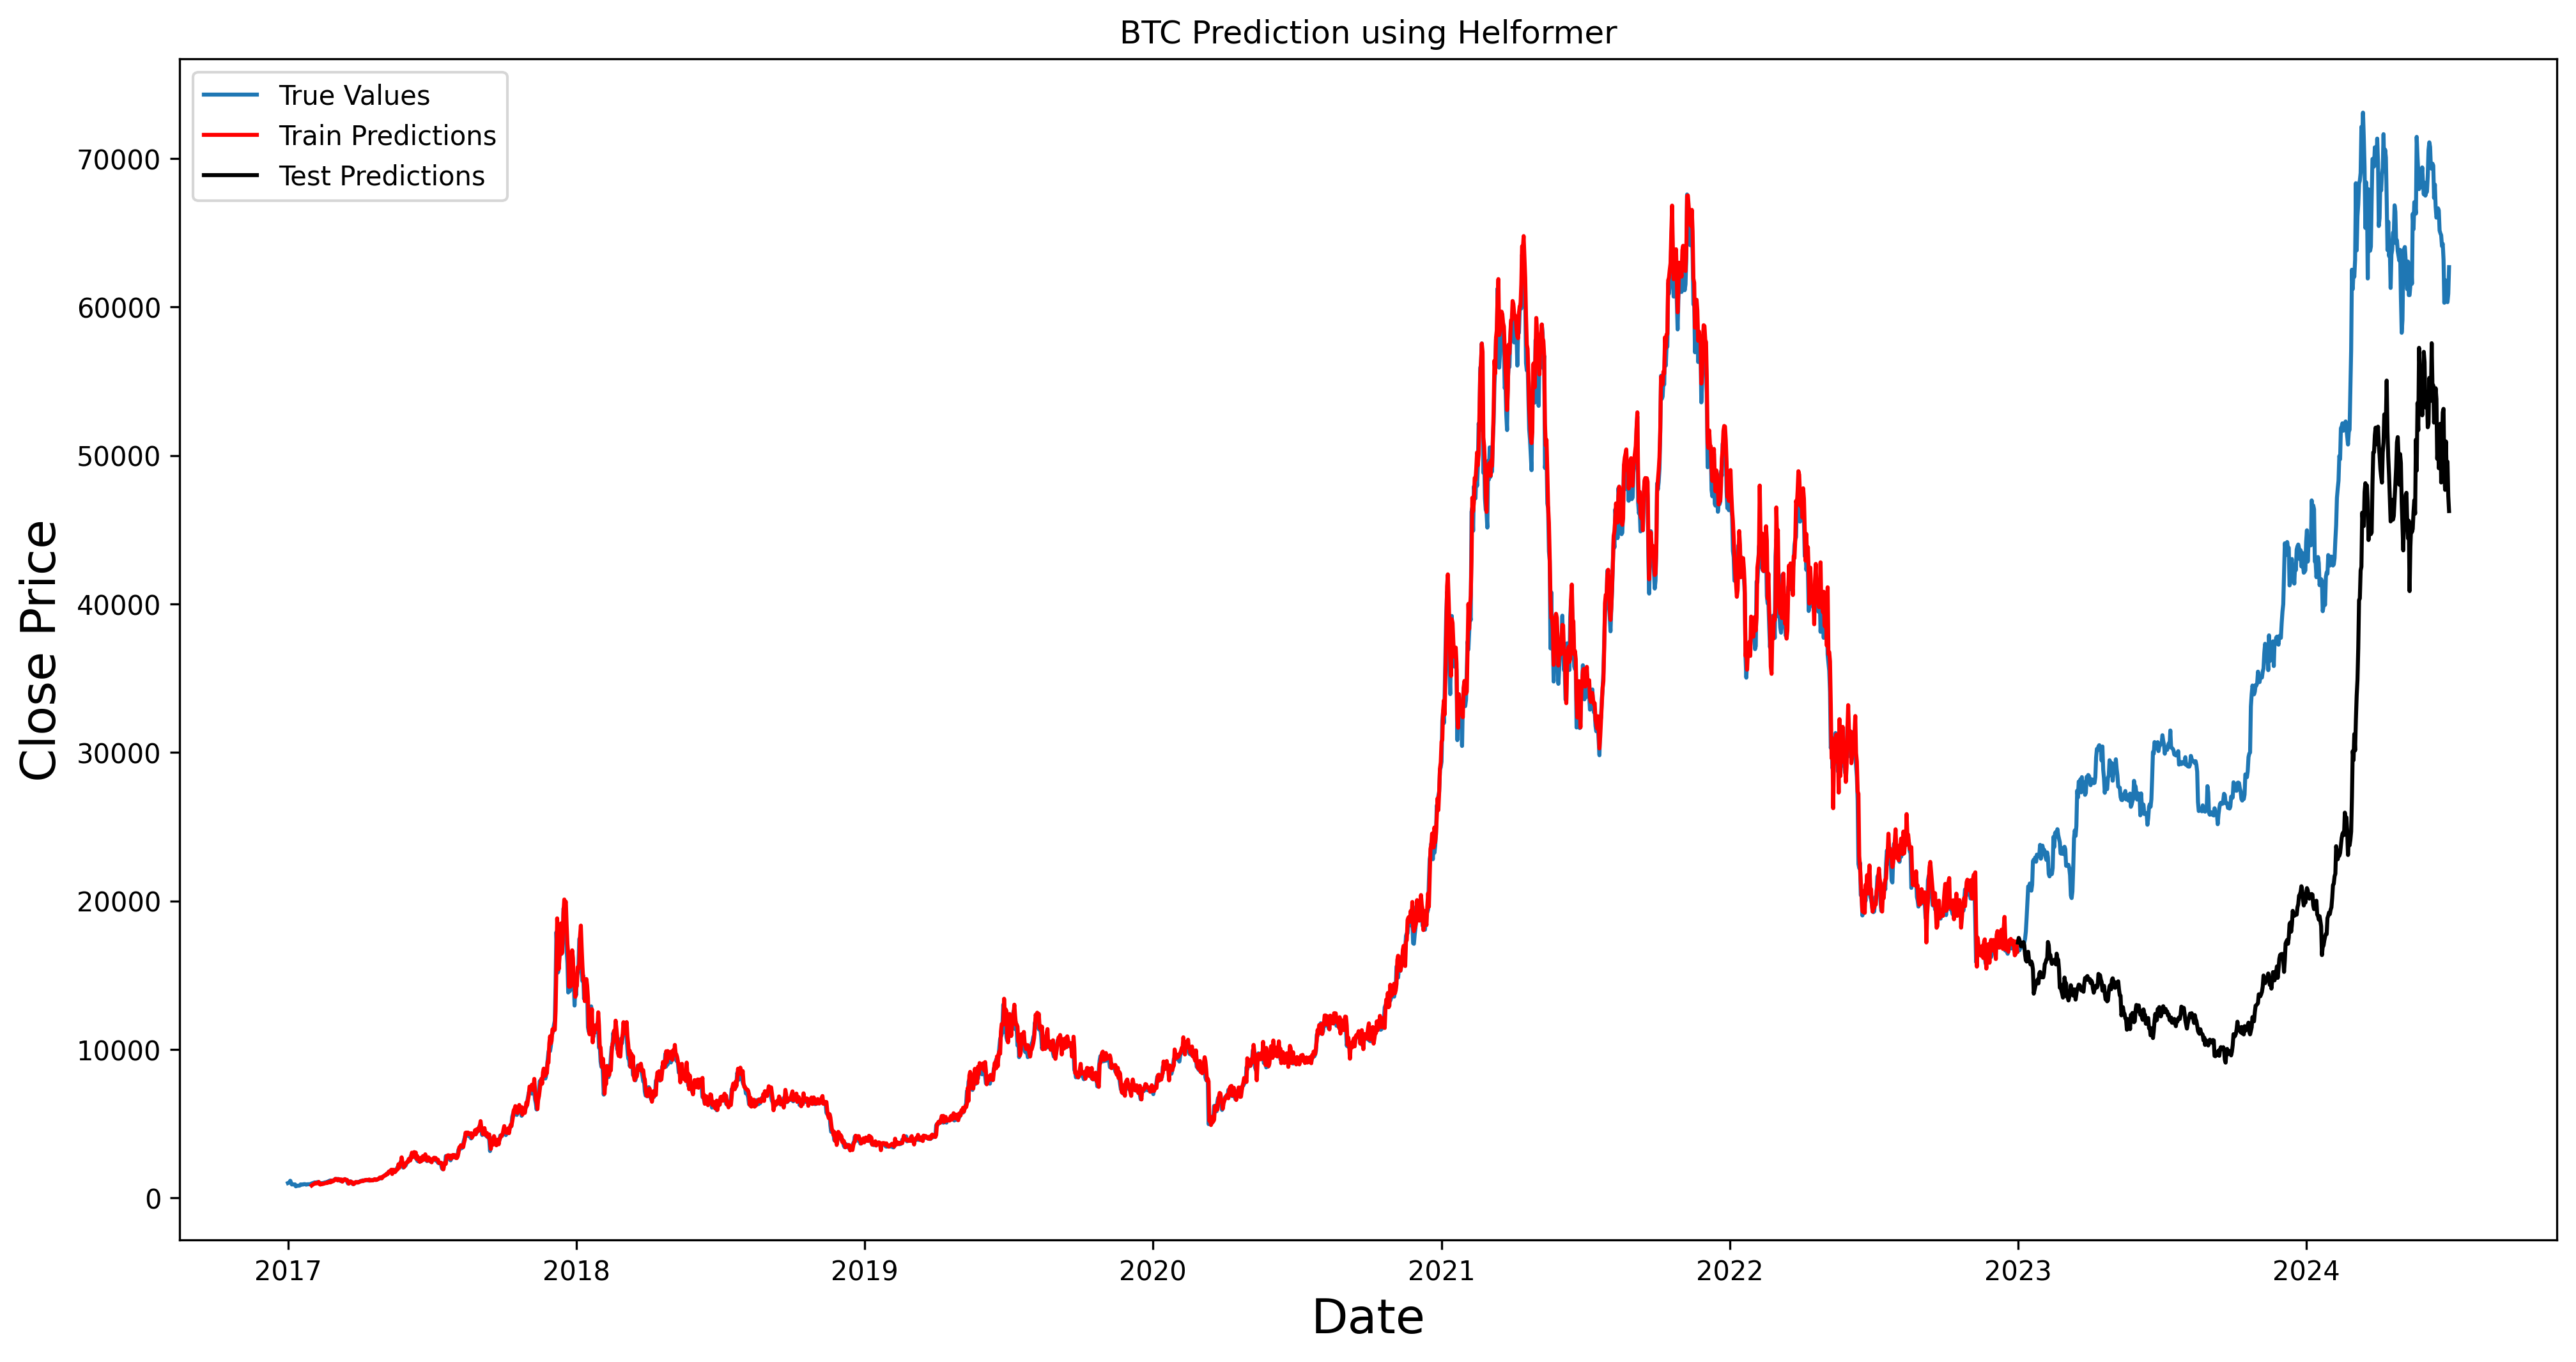

In [21]:
train_predictions = final_model_Helformer.predict(x_train)
train_predictions = scaler.inverse_transform(train_predictions).flatten()  # ratio_hat

# Convert ratio_hat -> close_hat using base_train
train_predictions = train_predictions * base_train.to_numpy()[time_step:training_data_len]

y_train_rescaled = scaler.inverse_transform(y_train.reshape(-1, 1)).flatten()  # ratio_true
y_train_rescaled = y_train_rescaled * base_train.to_numpy()[time_step:training_data_len]  # close_true

# Function to calculate MAPE
def mean_absolute_percentage_error(y_true, y_pred):
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

# Function to calculate KGE (Kling-Gupta Efficiency)
def kge(y_true, y_pred):
    cc = np.corrcoef(y_true, y_pred)[0, 1]  # Correlation coefficient
    alpha = np.std(y_pred) / np.std(y_true)  # Variability ratio
    beta = np.mean(y_pred) / np.mean(y_true)  # Bias ratio
    return 1 - np.sqrt((cc - 1) ** 2 + (alpha - 1) ** 2 + (beta - 1) ** 2)

# Predictions on testing data
print("Predicting test data")
test_predictions = final_model_Helformer.predict(x_test)
test_predictions = scaler.inverse_transform(test_predictions).flatten()  # ratio_hat

# Convert ratio_hat -> close_hat using base_test FORECAST (no leakage)
test_predictions = test_predictions * base_test.to_numpy()

# Calculate metrics for training data
train_mse = mean_squared_error(y_train_rescaled, train_predictions)
train_rmse = np.sqrt(train_mse)
train_mape = mean_absolute_percentage_error(y_train_rescaled, train_predictions)
train_mae = mean_absolute_error(y_train_rescaled, train_predictions)
train_r2 = r2_score(y_train_rescaled, train_predictions)
train_evs = explained_variance_score(y_train_rescaled, train_predictions)
train_kge = kge(y_train_rescaled, train_predictions)

# Calculate metrics for testing data
test_mse = mean_squared_error(y_test, test_predictions)
test_rmse = np.sqrt(test_mse)
test_mape = mean_absolute_percentage_error(y_test, test_predictions)
test_mae = mean_absolute_error(y_test, test_predictions)
test_r2 = r2_score(y_test, test_predictions)
test_evs = explained_variance_score(y_test, test_predictions)
test_kge = kge(y_test, test_predictions)

# Get current date and time
now = datetime.datetime.now()
timestamp = now.strftime("%Y-%m-%d_%H-%M-%S")
readable_time = now.strftime("%Y-%m-%d %H:%M:%S")

# Define file path and name
filename = f"Performance_metrics_{timestamp}.txt"
filepath = os.path.join("/kaggle/working/results/", filename)


# Write metrics to file
with open(filepath, 'w') as f:               # Change filename to filepath for codeocean
    f.write(f"::     ::\n")
    f.write(f"Training Data Evaluation Metrics\n")
    f.write(f"Timestamp: {readable_time}\n\n")
    f.write(f"MSE: {train_mse:.4f}\n")
    f.write(f"RMSE: {train_rmse:.4f}\n")
    f.write(f"MAPE: {train_mape:.4f}%\n")
    f.write(f"MAE: {train_mae:.4f}\n")
    f.write(f"R^2 Score: {train_r2:.4f}\n")
    f.write(f"Explained Variance Score (EVS): {train_evs:.4f}\n")
    f.write(f"KGE: {train_kge:.4f}\n")
    
    f.write(f"-----\n")
    f.write(f"Testing Data Evaluation Metrics\n")
    f.write(f"Timestamp: {readable_time}\n\n")
    f.write(f"MSE: {test_mse:.4f}\n")
    f.write(f"RMSE: {test_rmse:.4f}\n")
    f.write(f"MAPE: {test_mape:.4f}%\n")
    f.write(f"MAE: {test_mae:.4f}\n")
    f.write(f"R^2 Score: {test_r2:.4f}\n")
    f.write(f"Explained Variance Score (EVS): {test_evs:.4f}\n")
    f.write(f"KGE: {test_kge:.4f}\n")

print(f"Metrics saved to: {filename}")


# Plot the data
plt.figure(figsize=(16,8), dpi=300)
plt.title('BTC Prediction using Helformer')
plt.xlabel('Date', fontsize=18)
plt.ylabel('Close Price', fontsize=18)

# Plot original data
plt.plot(df['Close'], label='True Values')

# Create a list of NaNs to fill in the missing values in the plot
train_predictions_plot = [np.nan] * len(df)
train_predictions_plot[time_step:training_data_len] = train_predictions

# Add training predictions to the plot
plt.plot(df.index, train_predictions_plot, color='red', label='Train Predictions')

# Create a list of NaNs to fill in the missing values in the plot
test_predictions_plot = [np.nan] * len(df)
test_predictions_plot[training_data_len:] = test_predictions

# Add test predictions to the plot
plt.plot(df.index, test_predictions_plot, color='black', label='Test Predictions')

plt.legend()

plt.savefig ("/kaggle/working/results/Helformer_Predictions.png")


# Assuming observed_values = y_test and predicted_values = test_predictions
observed_values = y_test
predicted_values = test_predictions

# Initialize an array to store returns with transaction cost
returns_with_cost = []

for i in range(1, len(observed_values)):
    trade_signal = np.sign(predicted_values[i] - observed_values[i-1])

    Rt = np.log(observed_values[i] / observed_values[i-1]) * trade_signal

    # Apply transaction cost
    Rt_after_cost = Rt - 0.01 * abs(Rt)

    returns_with_cost.append(Rt_after_cost)

# Calculate net value (NV)
net_value = np.cumsum(returns_with_cost) + 1

# Calculate total returns
total_return = net_value[-1] - 1
total_return_pcnt = total_return * 100

# Calculate volatility (standard deviation of returns)
volatility = np.std(returns_with_cost)

# Calculate max drawdown
drawdowns = 1 - net_value / np.maximum.accumulate(net_value)
max_drawdown = np.max(drawdowns)
max_drawdown_inv = max_drawdown * -1

# Set annual risk-free rate (Rf) to 1%
risk_free_rate_annual = 0.01
risk_free_rate_daily = risk_free_rate_annual / 365  # Convert to daily risk-free rate

# Calculate Sharpe ratio
expected_return = np.mean(returns_with_cost)
sharpe_ratio = (expected_return - risk_free_rate_daily) / volatility * np.sqrt(365)

# Define file path and name
filename = f"Trading_metrics.txt"
filepath = os.path.join("/kaggle/working/results", filename)    #for code ocean

# Write metrics to file
with open(filepath, 'w') as f:                 
    f.write(f"::     ::\n")
    f.write(f"Trading Metrics\n")
    f.write(f"Timestamp: {readable_time}\n")
    f.write(f"Total Return: {total_return_pcnt:.4f}%\n")
    f.write(f"Volatility: {volatility:.4f}\n")
    f.write(f"Max Drawdown: {max_drawdown_inv:.4f}\n")
    f.write(f"Sharpe Ratio: {sharpe_ratio:.4f}\n")

print(f"Trading metrics saved to: {filename}")     # Change filename to filepath for codeocean

In [25]:
diff = np.abs(y_test - test_predictions)
print("max abs diff:", diff.max())
print("mean abs diff:", diff.mean())
print("allclose:", np.allclose(y_test, test_predictions))


max abs diff: 36123.62960925081
mean abs diff: 16912.655599143684
allclose: False


In [24]:
print("ratio_train std:", np.std(ratio_train))
print("ratio_test std:", np.std(ratio_test))

ratio_train std: 0.06846415697085402
ratio_test std: 15.049467966810669


In [23]:
diff = np.abs(y_test - test_predictions)
print(diff.max(), diff.mean(), np.allclose(y_test, test_predictions))


36123.62960925081 16912.655599143684 False
